Inputs shape: (36, 6)
Outputs shape: (36,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score  source
32     0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182  week-3
6      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968    file
30     0.000000     0.500000     0.214286     0.214286     0.428572     0.714286  1.181423  week-1
31     0.060606     0.484848     0.242424     0.181818     0.484848     0.727273  0.976917  week-2
24     0.881647     0.204450     0.414474     0.420385     0.264915     0.730660  0.675142    file
14     0.148647     0.033943     0.728806     0.316066     0.021769     0.516918  0.611526    file
0      0.272624     0.324495     0.897109     0.832951     0.154063     0.795864  0.604433    file
1      0.543003     0.924694     0.341567     0.646486     0.718440     0.343133  0.562753    file
25     0.066611     0.528045     0.8160

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 0.694839, Val Loss: 2.342209
Epoch 50/500, Train Loss: 0.210526, Val Loss: 1.766361
Epoch 100/500, Train Loss: 0.041979, Val Loss: 1.118878
Epoch 150/500, Train Loss: 0.000423, Val Loss: 0.993425
Early stopping at epoch 174, best val_loss=0.932721


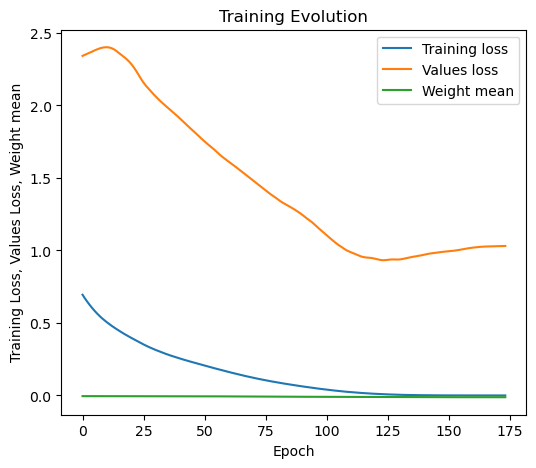

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


sample_strategy=sobol, Final sample shape: (100, 6)
Filtered 27 candidates using filter_strategy='good'
Predictions range (scaled): -0.8807 to 2.7852
Inverse-transforming predictions to raw units
Predictions range (raw): -0.0391 to 1.3960
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.0, 'kappa': None, 'x': array([0.04276118, 0.14528665, 0.69084939, 0.29132942, 0.28075761,
       1.06880755]), 'score': 0.46900291521749293, 'dim': 6, 'predicted_y': 1.3959907}
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.04276118, 0.14528665, 0.69084939, 0.29132942, 0.28075761,
       1.06880755]), 'score': 0.4626971088532851, 'dim': 6, 'predicted_y': 1.3959907}
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.04276118, 0.14528665, 0.69084939, 0.29132942, 0.28075761,
       1.06880755]), 'score': 0.22771393192004521, 'dim': 6, 'predicted_y': 1.3959907}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.04276118, 0.14528665, 0.69084939, 0.29132942, 0.28075761,
 

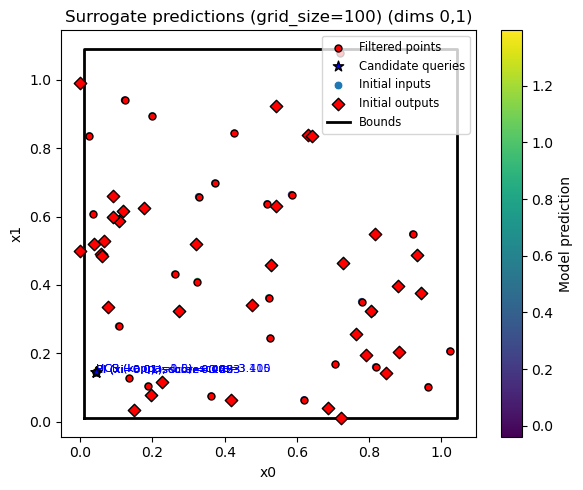

<Figure size 600x500 with 0 Axes>

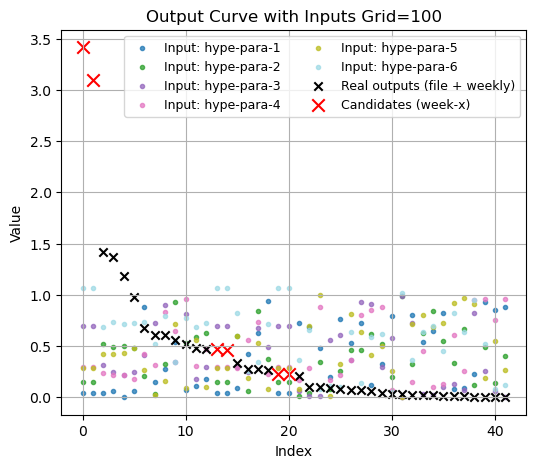

Saved dataframe to: results/run_2025-12-14 12-54-50/df_grid_100_stride6_median_max_raw_lr0.001_ep600.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.04276118, 0.14528665, 0.69084939, 0.29132942, 0.28075761,
       1.06880755]), 'score': 3.4154939361408463, 'dim': 6, 'predicted_y': 1.3959907}
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6     score  source  score-scaled
0      0.042761     0.145287     0.690849     0.291329     0.280758     1.068808  3.415494  week-x     10.000000
1      0.042761     0.145287     0.690849     0.291329     0.280758     1.068808  3.100328  week-x      9.077246
2      0.038479     0.518839     0.311248     0.237261     0.417124     0.684376  1.415182  week-3      4.143419
3      0.057896     0.491672     0.247422     0.218118     0.420428     0.730970  1.364968    file      3.996401
4      0.000000     0.500000     0.214286     0.214286     0.428572     0.714286  1.181423  week-1      3.459010

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))